# 1. IMPORT REQUIRED LIBRARIES

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2. LOAD THE TITANIC DATASET

In [8]:
# Load the Titanic dataset from Seaborn.
df = sns.load_dataset("titanic")

# Display the first few rows to verify that the dataset loaded correctly
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



# 3. SAVE OFFLINE FALLBACK DATASET

In [9]:
# Save the raw loaded dataset as a CSV.
df.to_csv("titanic.csv", index=False)

print("Titanic dataset saved successfully as titanic.csv")

Titanic dataset saved successfully as titanic.csv


# 4. BASIC DATA PROFILING

In [10]:
# Display dataset dimensions
print("Dataset Shape:", df.shape)

# Display information about columns, data types and non-null values
df.info()

# Display descriptive statistics for numerical columns
df.describe()

Dataset Shape: (891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



# 5. MISSING VALUE ANALYSIS

In [11]:

# Calculate the number of missing values in each column
missing_count = df.isnull().sum()

# Calculate the percentage of missing values in each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a summary DataFrame
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

# Show only columns that contain missing values
missing_summary = missing_summary[missing_summary["Missing Count"] > 0]

missing_summary

,Missing Count,Missing Percentage
age,177,19.865320
embarked,2,0.224467
deck,688,77.216611
embark_town,2,0.224467


# 6. Missing Value Handling

The missing-value strategy follows the percentage-based threshold specified in the project requirements.

- `age` has 19.8653% missing values, which falls between 5% and 30%. Therefore, missing age values are imputed using the median.
- `embarked` has 0.2245% missing values, which is below 5%. Therefore, the two affected rows are dropped.
- `embark_town` has 0.2245% missing values, which is below 5%. Therefore, the two affected rows are dropped.
- `deck` has 77.2166% missing values. Since the missingness is extremely high, the column is dropped rather than imputed.

In [12]:

# 6. HANDLE MISSING VALUES

# Drop the 'deck' column because 77.22% of its values are missing.
df = df.drop(columns=["deck"])

# Drop rows where 'embarked' or 'embark_town' is missing.
df = df.dropna(subset=["embarked", "embark_town"])

# Fill missing values in 'age' with the median.
age_median = df["age"].median()
df["age"] = df["age"].fillna(age_median)

# Display the remaining missing values
print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [13]:
# Check the new shape after cleaning
print("Shape after cleaning:", df.shape)

Shape after cleaning: (889, 14)


# 7. Univariate Analysis

Univariate analysis is performed on the `age` and `fare` variables to understand their distributions and identify potential outliers.

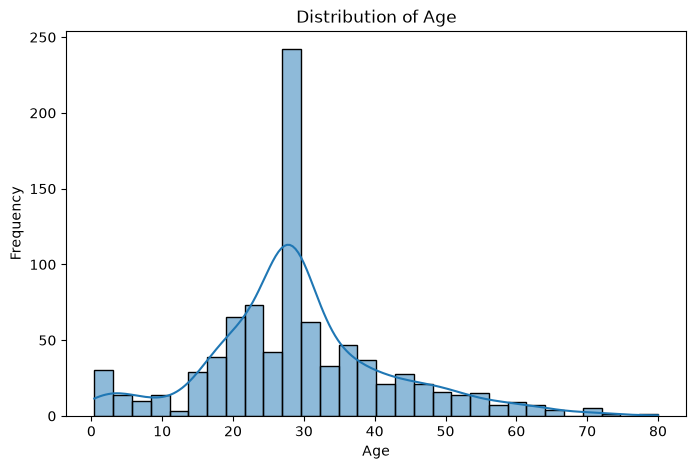

In [14]:
# 7.1 AGE DISTRIBUTION

# Create a figure for the Age histogram
plt.figure(figsize=(8, 5))

# Plot the distribution of Age
sns.histplot(data=df, x="age", bins=30, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

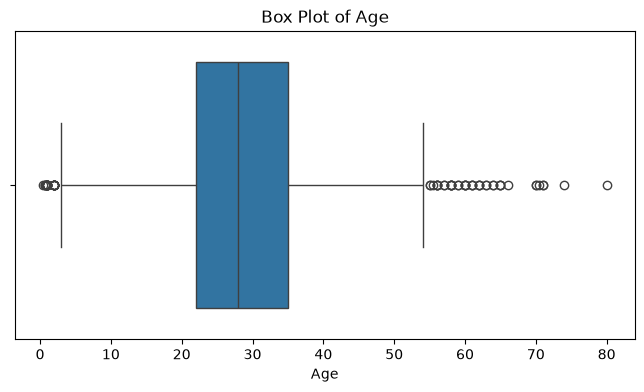

In [15]:
# 7.2 AGE BOXPLOT

plt.figure(figsize=(8, 4))

# Box plot helps identify potential Age outliers
sns.boxplot(x=df["age"])

plt.title("Box Plot of Age")
plt.xlabel("Age")
plt.show()

In [16]:
# 7.3 AGE OUTLIER DETECTION USING IQR

# Calculate the first and third quartiles
Q1_age = df["age"].quantile(0.25)
Q3_age = df["age"].quantile(0.75)

# Calculate the Interquartile Range
IQR_age = Q3_age - Q1_age

# Calculate lower and upper bounds
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

# Identify outliers
age_outliers = df[
    (df["age"] < lower_age) |
    (df["age"] > upper_age)
]

print("Age Q1:", Q1_age)
print("Age Q3:", Q3_age)
print("Age IQR:", IQR_age)
print("Age Lower Bound:", lower_age)
print("Age Upper Bound:", upper_age)
print("Number of Age Outliers:", len(age_outliers))

Age Q1: 22.0
Age Q3: 35.0
Age IQR: 13.0
Age Lower Bound: 2.5
Age Upper Bound: 54.5
Number of Age Outliers: 65


### Age Distribution Interpretation

The Age distribution is concentrated mainly around the 20–35 age range, with fewer passengers at very young and older ages. Using the IQR rule, the lower bound is 2.5 years and the upper bound is 54.5 years, resulting in 65 observations being identified as potential outliers. The box plot shows that most of these outliers occur toward the higher-age range.

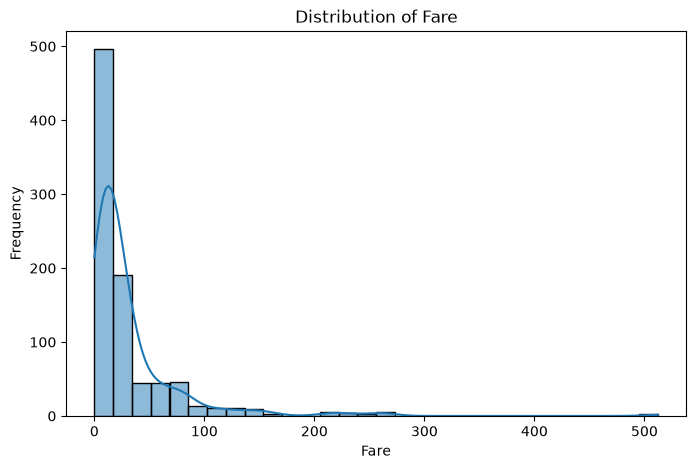

In [17]:
# 7.4 FARE DISTRIBUTION

plt.figure(figsize=(8, 5))

# Plot the distribution of Fare
sns.histplot(data=df, x="fare", bins=30, kde=True)

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

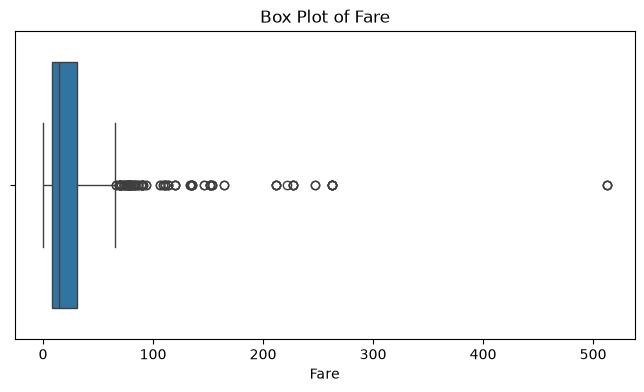

In [18]:
# 7.5 FARE BOXPLOT

plt.figure(figsize=(8, 4))

# Box plot helps identify potential Fare outliers
sns.boxplot(x=df["fare"])

plt.title("Box Plot of Fare")
plt.xlabel("Fare")
plt.show()

In [19]:
# 7.6 FARE OUTLIER DETECTION USING IQR

# Calculate quartiles
Q1_fare = df["fare"].quantile(0.25)
Q3_fare = df["fare"].quantile(0.75)

# Calculate IQR
IQR_fare = Q3_fare - Q1_fare

# Calculate outlier boundaries
lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

# Identify Fare outliers
fare_outliers = df[
    (df["fare"] < lower_fare) |
    (df["fare"] > upper_fare)
]

print("Fare Q1:", Q1_fare)
print("Fare Q3:", Q3_fare)
print("Fare IQR:", IQR_fare)
print("Fare Lower Bound:", lower_fare)
print("Fare Upper Bound:", upper_fare)
print("Number of Fare Outliers:", len(fare_outliers))

Fare Q1: 7.8958
Fare Q3: 31.0
Fare IQR: 23.1042
Fare Lower Bound: -26.7605
Fare Upper Bound: 65.6563
Number of Fare Outliers: 114


In [20]:
# 7.7 FARE STATISTICAL SUMMARY

fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05


### Fare Distribution Interpretation

The Fare distribution is strongly right-skewed, as most passengers paid relatively low fares while a smaller number of passengers paid substantially higher fares. The mean fare (32.10) is greater than the median (14.45), which is greater than the mode (8.05), confirming positive skewness. The box plot identifies 114 observations as outliers using the IQR rule, mainly on the higher-fare side.

# 8. Bivariate Analysis

Bivariate analysis is used to examine the relationship between passenger characteristics and survival.

The survival rate is calculated as the mean of the `survived` column, where:
- `0` represents did not survive
- `1` represents survived

The analysis examines survival rates by sex, passenger class, and the combination of sex and passenger class.

In [22]:
# 8.1 SURVIVAL RATE BY SEX

# Select passengers by sex using boolean masking
female_passengers = df[df["sex"] == "female"]
male_passengers = df[df["sex"] == "male"]

# Calculate survival rates
female_survival_rate = female_passengers["survived"].mean() * 100
male_survival_rate = male_passengers["survived"].mean() * 100

print(f"Female survival rate: {female_survival_rate:.2f}%")
print(f"Male survival rate: {male_survival_rate:.2f}%")

Female survival rate: 74.04%
Male survival rate: 18.89%


### Survival Rate by Sex — Interpretation

Female passengers had a substantially higher survival rate of 74.04%, compared with only 18.89% for male passengers. This indicates that sex was a strong factor associated with survival in the Titanic dataset, with female passengers being much more likely to survive than male passengers.

#
#

In [24]:
# 8.2 SURVIVAL RATE BY PASSENGER CLASS

# Select passengers from each passenger class using boolean masking
first_class = df[df["pclass"] == 1]
second_class = df[df["pclass"] == 2]
third_class = df[df["pclass"] == 3]

# Calculate survival rates
first_class_survival = first_class["survived"].mean() * 100
second_class_survival = second_class["survived"].mean() * 100
third_class_survival = third_class["survived"].mean() * 100

print(f"1st Class survival rate: {first_class_survival:.2f}%")
print(f"2nd Class survival rate: {second_class_survival:.2f}%")
print(f"3rd Class survival rate: {third_class_survival:.2f}%")

1st Class survival rate: 62.62%
2nd Class survival rate: 47.28%
3rd Class survival rate: 24.24%


### Survival Rate by Passenger Class — Interpretation

First-class passengers had the highest survival rate at 62.62%, followed by second-class passengers at 47.28%. Third-class passengers had a much lower survival rate of 24.24%, suggesting that passenger class was strongly associated with survival.

# 

In [25]:
# 8.3 SURVIVAL RATE BY SEX AND PASSENGER CLASS

# Female passengers in each class
female_first = df[(df["sex"] == "female") & (df["pclass"] == 1)]
female_second = df[(df["sex"] == "female") & (df["pclass"] == 2)]
female_third = df[(df["sex"] == "female") & (df["pclass"] == 3)]

# Male passengers in each class
male_first = df[(df["sex"] == "male") & (df["pclass"] == 1)]
male_second = df[(df["sex"] == "male") & (df["pclass"] == 2)]
male_third = df[(df["sex"] == "male") & (df["pclass"] == 3)]

# Calculate survival rates
print(f"Female, 1st Class: {female_first['survived'].mean() * 100:.2f}%")
print(f"Female, 2nd Class: {female_second['survived'].mean() * 100:.2f}%")
print(f"Female, 3rd Class: {female_third['survived'].mean() * 100:.2f}%")

print(f"Male, 1st Class: {male_first['survived'].mean() * 100:.2f}%")
print(f"Male, 2nd Class: {male_second['survived'].mean() * 100:.2f}%")
print(f"Male, 3rd Class: {male_third['survived'].mean() * 100:.2f}%")

Female, 1st Class: 96.74%
Female, 2nd Class: 92.11%
Female, 3rd Class: 50.00%
Male, 1st Class: 36.89%
Male, 2nd Class: 15.74%
Male, 3rd Class: 13.54%


In [26]:
# 8.4 SEX + PCLASS SURVIVAL SUMMARY

# Group by both sex and passenger class
sex_pclass_survival = (
    df.groupby(["sex", "pclass"])["survived"]
    .mean()
    .mul(100)
    .reset_index(name="survival_rate")
)

# Round the survival rate
sex_pclass_survival["survival_rate"] = (
    sex_pclass_survival["survival_rate"].round(2)
)

sex_pclass_survival

,sex,pclass,survival_rate
0,female,1,96.74
1,female,2,92.11
2,female,3,50.00
3,male,1,36.89
4,male,2,15.74
5,male,3,13.54


### Survival Rate by Sex and Passenger Class — Interpretation

The combination of sex and passenger class shows an even clearer difference in survival. Female first-class passengers had the highest survival rate at 96.74%, while male third-class passengers had the lowest at 13.54%. Among both sexes, higher passenger class was generally associated with higher survival, while females consistently had higher survival rates than males within the same class.
#
#
#

#
#


# 9. Correlation Analysis

Correlation analysis is performed to examine the linear relationships among the specified numerical variables. The analysis uses exactly six columns: `survived`, `pclass`, `age`, `sibsp`, `parch`, and `fare`.

In [27]:

# 9.1 SELECT REQUIRED NUMERICAL COLUMNS
# The capstone requires exactly these six columns
corr_cols = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

# Create the correlation DataFrame
corr_df = df[corr_cols]

# Calculate the correlation matrix
correlation_matrix = corr_df.corr()

# Display the correlation matrix
correlation_matrix

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


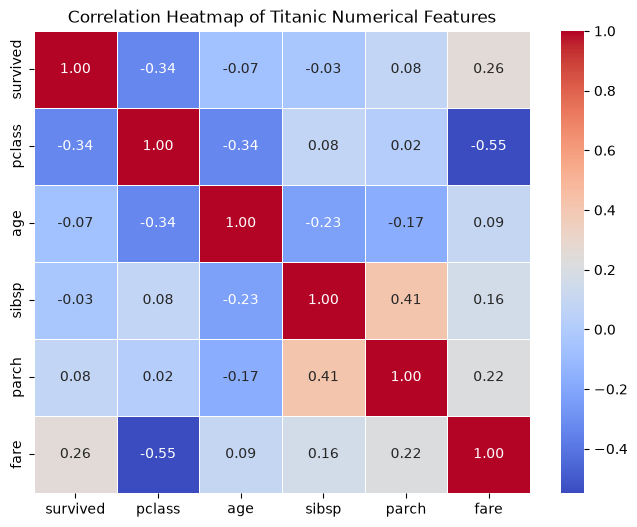

In [28]:
# 9.2 CORRELATION HEATMAP

plt.figure(figsize=(8, 6))

# Visualize the 6 × 6 correlation matrix
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Titanic Numerical Features")
plt.show()

### Interpretation of the Two Strongest Correlations

The strongest correlation is between `pclass` and `fare`, with a correlation coefficient of -0.5482. This moderate negative relationship indicates that passengers with higher numerical passenger-class values generally had lower fares; in the Titanic dataset, higher `pclass` values represent lower passenger classes.

The second strongest correlation is between `pclass` and `age`, with a correlation coefficient of -0.3365. This weak-to-moderate negative relationship indicates that passengers in higher numerical passenger classes tended to be somewhat younger, although the relationship is not particularly strong.

#
#

# 10. Multivariate Analysis

Multivariate analysis is used to examine the combined relationship between multiple passenger characteristics and Titanic survival.

The following visualizations analyze survival using combinations of sex, passenger class, age, and fare to develop a coherent understanding of who was more likely to survive and why.

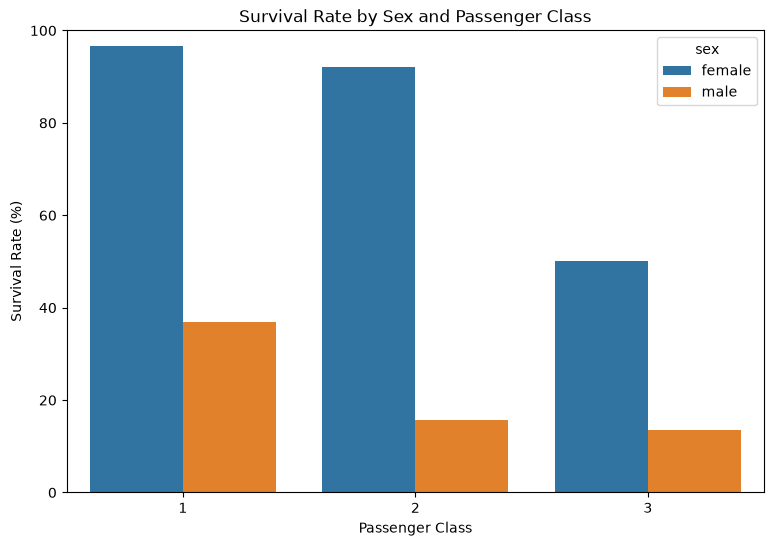

In [34]:
# 10.1 SURVIVAL RATE BY SEX AND PASSENGER CLASS

# Calculate survival rate for each combination of sex and class
sex_pclass_survival = (
    df.groupby(["sex", "pclass"])["survived"]
    .mean()
    .mul(100)
    .reset_index()
)

# Create grouped bar chart
plt.figure(figsize=(9, 6))

sns.barplot(
    data=sex_pclass_survival,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

plt.show()

### Interpretation
Survival was strongly influenced by the combination of sex and passenger class. Female passengers had substantially higher survival rates than male passengers across all three passenger classes. First-class females had the highest survival rate, while third-class males had the lowest, showing that both sex and socioeconomic class were important factors associated with survival.

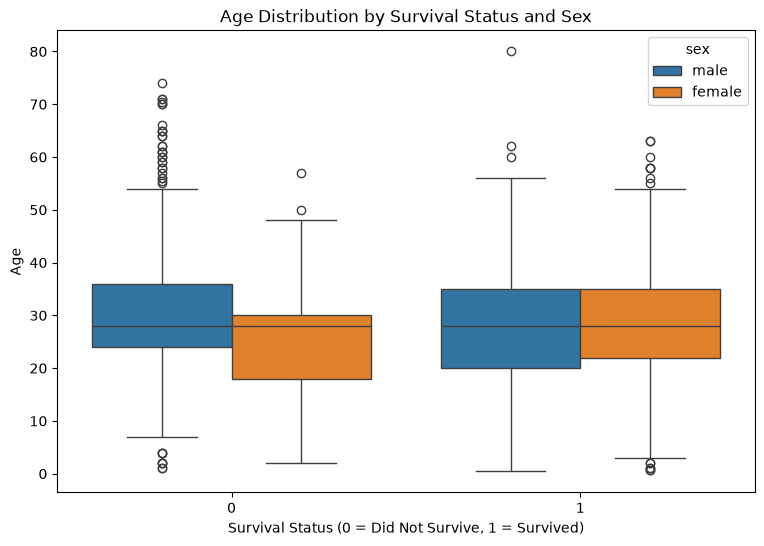

In [35]:
# 10.2 AGE DISTRIBUTION BY SURVIVAL AND SEX

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="survived",
    y="age",
    hue="sex"
)

plt.title("Age Distribution by Survival Status and Sex")
plt.xlabel("Survival Status (0 = Did Not Survive, 1 = Survived)")
plt.ylabel("Age")

plt.show()

### Interpretation

The age distributions show differences between survivors and non-survivors for both males and females. Female survivors and non-survivors have relatively similar median ages, while male survivors show a wider age distribution with several older-age outliers. Overall, age provides additional context for survival, but the differences appear less pronounced than the strong survival differences associated with sex.

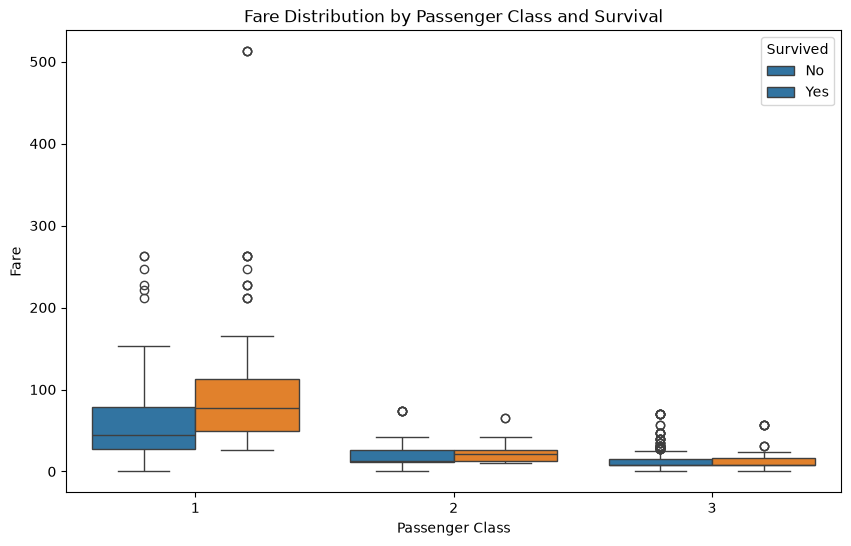

In [36]:
# 10.3 FARE DISTRIBUTION BY SURVIVAL AND PASSENGER CLASS

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="pclass",
    y="fare",
    hue="survived"
)

plt.title("Fare Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)

plt.show()

### Interpretation

Fare distributions vary substantially across passenger classes, with first-class passengers generally paying much higher fares than second- and third-class passengers. Within first class, survivors tend to have higher fares than non-survivors, while the difference is smaller in the lower classes. This suggests that fare, which is strongly related to passenger class, provides additional socioeconomic context for understanding survival.

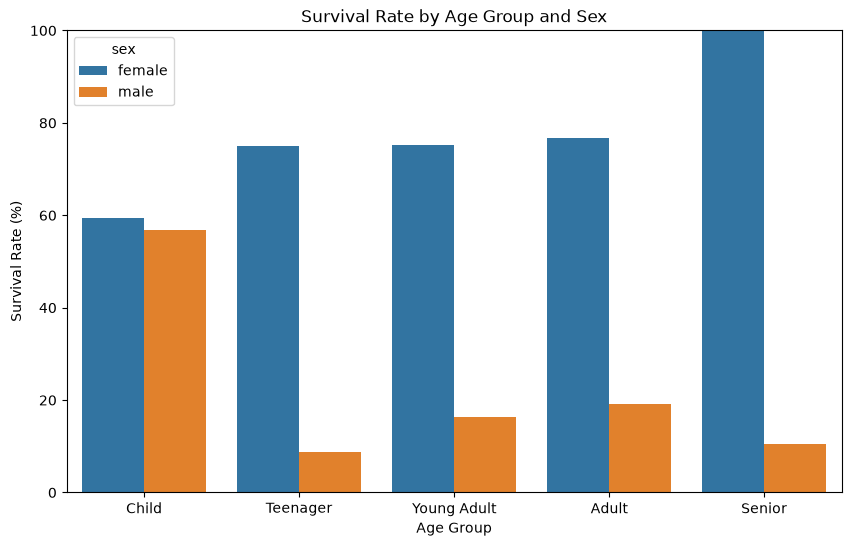

In [37]:
# 10.4 SURVIVAL RATE BY AGE GROUP AND SEX

# Create meaningful age groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 35, 60, np.inf],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

# Calculate survival rate by age group and sex
age_sex_survival = (
    df.groupby(["age_group", "sex"], observed=True)["survived"]
    .mean()
    .mul(100)
    .reset_index()
)

# Create grouped bar chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=age_sex_survival,
    x="age_group",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Age Group and Sex")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

plt.show()

### Interpretation

Survival rates vary across age groups and differ substantially between males and females. Female passengers generally had higher survival rates than males across the age groups, while the difference was much smaller among children. The very high survival rate observed for senior females should be interpreted cautiously because the number of passengers in individual age-sex groups may be small.

In [ ]:
# 10.6 EDA Feature Cleanup
#The `age_group` variable was created only for multivariate visualization and is not part of the original dataset. It was therefore removed before proceeding to the modeling stage.
# REMOVE EDA-ONLY FEATURE

# Remove the age_group column created only for visualization
df = df.drop(columns=["age_group"])

# Verify the dataset after cleanup
print("Current dataset shape:", df.shape)
print("\nCurrent columns:")
print(df.columns.tolist())

Current dataset shape: (889, 14)

Current columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


## 10.7 Standardization Sanity Check

Z-score standardization transforms a numerical variable using its mean and standard deviation:

$$
z = \frac{x - \mu}{\sigma}
$$

This sanity check standardizes `age` and `fare` using the full cleaned DataFrame and verifies that their transformed means are approximately 0 and standard deviations are approximately 1.

This standardized data is used only for EDA validation and will not be used as the preprocessing input for the machine learning models.

In [39]:
# 10.7 STANDARDIZATION SANITY CHECK

# Select the numerical columns required for standardization
standardize_cols = ["age", "fare"]

# Display statistics before standardization
print("Before Standardization:")
print(df[standardize_cols].agg(["mean", "std"]))

# Apply Z-score standardization
standardized_df = df[standardize_cols].copy()

standardized_df = (
    standardized_df - standardized_df.mean()
) / standardized_df.std()

# Display statistics after standardization
print("\nAfter Standardization:")
print(standardized_df.agg(["mean", "std"]))

Before Standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After Standardization:
               age          fare
mean  2.797412e-16  1.358743e-16
std   1.000000e+00  1.000000e+00


### Interpretation

After Z-score standardization, the means of `age` and `fare` are effectively 0, while their standard deviations are exactly 1. This confirms that the standardization procedure was applied correctly. The standardized values are used only as an EDA sanity check and will not be used directly in the modeling preprocessing pipeline.